## Model Training & Evaluation

### Train Multiple ML Models

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load clean data and saved split
X_train, X_test, y_train, y_test = joblib.load('../models/train_test_split.pkl')

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 811
Testing samples:  203


In [4]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = {}

print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'CV Score':>10}")
print("=" * 50)

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Test accuracy
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # 5-fold cross validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    results[name] = {'accuracy': acc, 'cv_score': cv_mean, 'model': model}
    print(f"{name:<25} {acc*100:>9.2f}%  {cv_mean*100:>9.2f}%")

print("=" * 50)

Model                       Accuracy   CV Score
Random Forest                 85.71%      80.40%
XGBoost                       84.73%      82.62%
Logistic Regression           65.02%      59.31%
KNN                           67.49%      68.68%


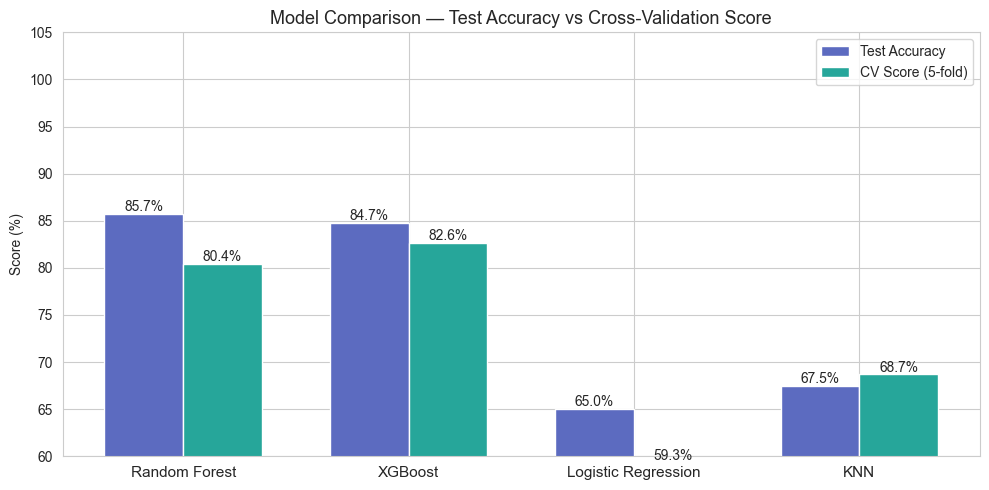

In [5]:
# --- Model Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
accuracies = [results[n]['accuracy'] * 100 for n in names]
cv_scores = [results[n]['cv_score'] * 100 for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width,
               label='Test Accuracy', color='#5C6BC0', edgecolor='white')
bars2 = ax.bar(x + width/2, cv_scores, width,
               label='CV Score (5-fold)', color='#26A69A', edgecolor='white')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Test Accuracy vs Cross-Validation Score', fontsize=13)
ax.set_ylim(60, 105)
ax.legend()
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

### Deep Evaluation of Best Model

In [6]:
# Select best model
best_name = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']
y_pred = best_model.predict(X_test)

print(f"Best model: {best_name}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred)*100:.2f}%\n")

# --- Classification Report ---
target_names = ['Low Risk', 'Mid Risk', 'High Risk']
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=target_names))

Best model: Random Forest
Accuracy:   85.71%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Low Risk       0.87      0.83      0.85        81
    Mid Risk       0.81      0.81      0.81        67
   High Risk       0.90      0.96      0.93        55

    accuracy                           0.86       203
   macro avg       0.86      0.87      0.86       203
weighted avg       0.86      0.86      0.86       203



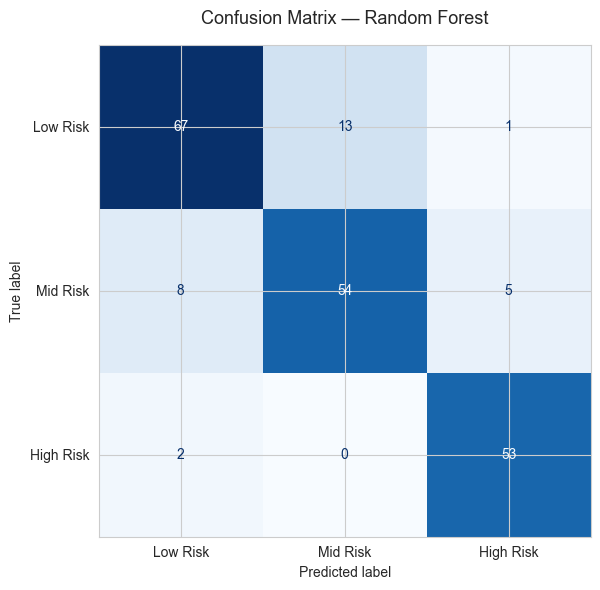

In [8]:
# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

In [9]:
# --- Per-class Recall Focus (critical for medical systems) ---
from sklearn.metrics import recall_score, precision_score, f1_score

print("Per-class breakdown (medical focus):\n")
print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)

for i, name in enumerate(target_names):
    precision = precision_score(y_test, y_pred, average=None)[i]
    recall    = recall_score(y_test, y_pred, average=None)[i]
    f1        = f1_score(y_test, y_pred, average=None)[i]
    flag = " ← watch this" if name == "High Risk" else ""
    print(f"{name:<12} {precision*100:>9.1f}%  {recall*100:>9.1f}%  {f1*100:>9.1f}%{flag}")

Per-class breakdown (medical focus):

Class         Precision     Recall         F1
---------------------------------------------
Low Risk          87.0%       82.7%       84.8%
Mid Risk          80.6%       80.6%       80.6%
High Risk         89.8%       96.4%       93.0% ← watch this


### Hyperparameter Tuning

In [10]:
# --- GridSearchCV on Random Forest ---
print("Running GridSearchCV (this takes 2–3 minutes)...\n")

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features':  ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',   # balanced across all 3 classes
    n_jobs=-1,            # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV score: {grid_search.best_score_*100:.2f}%")

Running GridSearchCV (this takes 2–3 minutes)...

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters found:
  max_depth: None
  max_features: sqrt
  min_samples_split: 2
  n_estimators: 200

Best CV score: 81.74%


In [11]:
# Evaluate tuned model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"\nTuned model accuracy:   {tuned_acc*100:.2f}%")
print(f"Original model accuracy:{accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Improvement:            {(tuned_acc - accuracy_score(y_test, y_pred))*100:+.2f}%")

print("\nTuned Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))


Tuned model accuracy:   85.22%
Original model accuracy:85.71%
Improvement:            -0.49%

Tuned Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.86      0.83      0.84        81
    Mid Risk       0.82      0.79      0.80        67
   High Risk       0.88      0.96      0.92        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.86       203
weighted avg       0.85      0.85      0.85       203



### Feature Importance Analysis

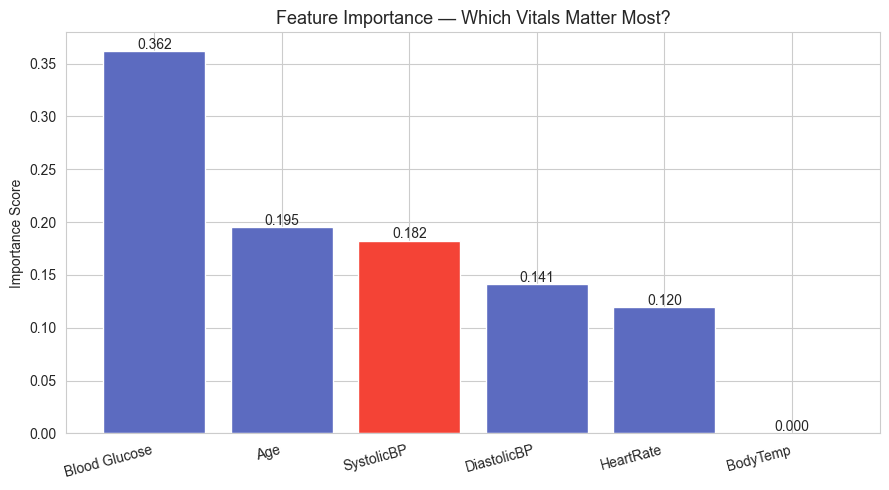


Feature rankings:
  1. Blood Glucose        0.3615
  2. Age                  0.1950
  3. SystolicBP           0.1825
  4. DiastolicBP          0.1414
  5. HeartRate            0.1195
  6. BodyTemp             0.0000


In [12]:
# --- Feature Importance Plot ---
features = ['Age', 'SystolicBP', 'DiastolicBP',
            'Blood Glucose', 'BodyTemp', 'HeartRate']

importances = tuned_model.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#F44336' if i == indices[0] else '#5C6BC0' for i in range(len(features))]
bars = ax.bar(range(len(features)),
              importances[indices],
              color=[colors[list(indices).index(i)] for i in range(len(features))],
              edgecolor='white')

ax.set_xticks(range(len(features)))
ax.set_xticklabels([features[i] for i in indices], rotation=15, ha='right')
ax.set_ylabel('Importance Score')
ax.set_title('Feature Importance — Which Vitals Matter Most?', fontsize=13)

for bar, imp in zip(bars, importances[indices]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{imp:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("\nFeature rankings:")
for rank, i in enumerate(indices):
    print(f"  {rank+1}. {features[i]:<20} {importances[i]:.4f}")

In [14]:
# Save tuned model and all artifacts
joblib.dump(tuned_model, '../models/model.pkl')
joblib.dump(tuned_model, '../models/best_model.pkl')  # backup

# Save feature names for the Flask app
import json
model_meta = {
    'features': features,
    'target_names': target_names,
    'model_name': 'Random Forest (Tuned)',
    'accuracy': round(tuned_acc * 100, 2)
}

with open('../models/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print("Saved successfully:")
print("  ✓ models/model.pkl")
print("  ✓ models/scaler.pkl     (saved in Phase 2)")
print("  ✓ models/model_meta.json")
print(f"\nFinal model accuracy: {tuned_acc*100:.2f}%")


Saved successfully:
  ✓ models/model.pkl
  ✓ models/scaler.pkl     (saved in Phase 2)
  ✓ models/model_meta.json

Final model accuracy: 85.22%
